# STEP 07 — Is the NPE's reported SE correct?

STEP 05 reports a posterior SD for every fit and STEP 06 plots its mean, but
neither checks whether that number is *right*. This notebook does, by
Monte-Carlo replication.

## The idea

Fix a parameter setting $(A, C, E)$ and a sample size $N$. Simulate a fresh
twin dataset **many times**, fit each with the NPE, and collect the estimates.
Then:

- the **spread of those estimates across replicates** is the true sampling
  SE — the thing a standard error is supposed to be;
- the **mean of the reported posterior SDs** is what the NPE *claims*
  its SE is.

Their ratio is the calibration. This is only meaningful because every
replicate holds the true parameters fixed — averaging across *different*
conditions (as STEP 06's old "SD of estimates" panel did) measures the spread
of the conditions themselves, not precision.

The cell below (after loading the data) works through exactly what each of
the three calibration metrics measures and why, with the math spelled out —
see also README.md Part 5 for the same content in prose form.

## Input

`results/simulations/npe_se_montecarlo.csv`, produced by:

```bash
python 05_simulate_posterior_recovery.py --model_dir se_proxy \
       --n_conditions 24 --n_reps 200 --output npe_se_montecarlo.csv
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sys.path.insert(0, str(Path.cwd()))
from ace_model import SIM_DIR, SE_CAL_DIR, ACE_PARAM_NAMES

SE_CAL_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name, dpi=150):
    path = SE_CAL_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"  figure -> {path.relative_to(SE_CAL_DIR.parents[1])}")
    return path


def save_table(df, name):
    path = SE_CAL_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"  table  -> {path.relative_to(SE_CAL_DIR.parents[1])}")
    return path


mc = pd.read_csv(SIM_DIR / "npe_se_montecarlo.csv")

PARAMS       = ACE_PARAM_NAMES
SAMPLE_SIZES = sorted(mc["sample_size"].unique())
CONDITIONS   = sorted(mc["condition_id"].unique())
N_REPS       = int(mc.groupby(["condition_id", "sample_size"]).size().min())

print(f"rows          : {len(mc):,}")
print(f"conditions    : {len(CONDITIONS)}  {CONDITIONS}")
print(f"sample sizes  : {SAMPLE_SIZES}")
print(f"replicates    : {N_REPS} per (condition, sample size)")
print(f"MC precision  : +/-{100/np.sqrt(2*(N_REPS-1)):.1f}% on each mc_se")


rows          : 33,600
conditions    : 24  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
sample sizes  : [np.int64(50), np.int64(100), np.int64(200), np.int64(500), np.int64(1000), np.int64(2000), np.int64(20000)]
replicates    : 200 per (condition, sample size)
MC precision  : +/-5.0% on each mc_se


## The math behind the three metrics

Fix $\theta_0=(A,C,E)$ and $N$. Draw $R$ independent datasets
$x_1,\dots,x_R\sim p(x\mid\theta_0)$ and fit each with the trained posterior
$q_\phi(\theta\mid x)$, giving a posterior mean $\hat\theta_r$ and posterior SD
$s_r$ per replicate.

### 1. `mc_se` — the true sampling SE

$$
\texttt{mc\_se} = \sqrt{\frac{1}{R-1}\sum_{r=1}^R (\hat\theta_r-\bar{\hat\theta})^2}
$$

the textbook definition of a standard error, obtained by literally sampling
the estimator's sampling distribution rather than approximating it. It carries
its own Monte-Carlo error: for $(R-1)S^2/\sigma^2\sim\chi^2_{R-1}$,
$\operatorname{Var}(S^2)=2\sigma^4/(R-1)$, and the delta method gives

$$
\frac{\mathrm{SD}(S)}{\sigma} \approx \frac{1}{\sqrt{2(R-1)}}
$$

— printed above as the MC precision. A ratio that differs from 1 by less than
this margin is noise, not miscalibration.

### 2. `ratio_se` — not expected to equal 1 at finite $N$

$$
\overline{s} = \frac1R\sum_{r=1}^R s_r, \qquad
\texttt{ratio\_se} = \frac{\overline{s}}{\texttt{mc\_se}}
$$

The posterior is a **shrinkage estimator**: with an informative prior,
$\hat\theta(x)$ is pulled toward the prior mean, which *reduces* the sampling
variance of $\hat\theta$ below what the posterior SD reports. A minimal
Normal–Normal model makes this exact: with
$\hat\theta_{\mathrm{lik}}(x)\sim\mathcal N(\theta_0,\sigma_{\mathrm{lik}}^2)$ and prior
$\theta\sim\mathcal N(\mu_0,\sigma_0^2)$, conjugacy gives posterior variance
$\sigma_{\mathrm{post}}^2=w\sigma_{\mathrm{lik}}^2$ with
$w=\sigma_0^2/(\sigma_0^2+\sigma_{\mathrm{lik}}^2)$, while the sampling variance of the
posterior mean is $\operatorname{Var}_x[\hat\theta_{\mathrm{Bayes}}]=w^2\sigma_{\mathrm{lik}}^2$.
So

$$
\texttt{ratio\_se} = \frac{\sigma_{\mathrm{post}}}{w\,\sigma_{\mathrm{lik}}} = \frac{1}{\sqrt w} \;\ge\; 1,
$$

equal to 1 only as $w\to1$, i.e. $N\to\infty$ (Bernstein–von Mises: the
posterior becomes asymptotically Gaussian with covariance matching the
frequentist sampling covariance once the likelihood dominates the prior).
`ratio_se` > 1 at finite $N$ is therefore the **expected signature of a
correctly calibrated** posterior, not evidence against one.

### 3. `ratio_rmse` — the Bayes-risk identity, and why *pooling* matters

$$
\texttt{rmse} = \sqrt{\tfrac1R\sum_r(\hat\theta_r-\theta_0)^2}, \qquad
\texttt{ratio\_rmse} = \frac{\overline{s}}{\texttt{rmse}}
$$

For the posterior mean under squared error, decision theory gives an *exact*
identity — averaged over the same $\theta\sim p(\theta),\ x\sim p(x\mid\theta)$
used in training:

$$
\underbrace{\mathbb E_{\theta,x}[(\theta-\hat\theta(x))^2]}_{\text{Bayes risk}}
= \mathbb E_x[\operatorname{Var}(\theta\mid x)]
$$

(tower rule: conditioning on $x$ first, $\mathbb
E_{\theta\mid x}[(\theta-\hat\theta(x))^2]=\operatorname{Var}(\theta\mid x)$ exactly,
since $\hat\theta(x)$ *is* the posterior mean). So $\overline{s^2}\approx
\texttt{rmse}^2$ once averaged over a representative sample of $\theta$ — which
is what pooling `ratio_rmse` over many conditions approximates, and why it is
the fairer target than the single-condition `ratio_se`. Caveat: the test
conditions are Dirichlet($1,1,1$) draws ($A+C+E=1$), not the pipeline's actual
training prior (independent $\mathcal U(0,1)^3$, no sum constraint) — the
identity is exact only when the pooling distribution matches the training
prior, so residual drift from 1 partly reflects that mismatch.

### 4. `coverage95` — marginal vs. pointwise

$$
\texttt{coverage95} = \frac1R\sum_{r=1}^R \mathbb 1\big[\theta_0\in[q_{2.5}(\theta\mid x_r),\,q_{97.5}(\theta\mid x_r)]\big]
$$

A 95% credible interval satisfies $P(\theta\in\mathrm{CI}(x)\mid x)=0.95$ for
every $x$ by construction, so averaging over the joint $(\theta,x)$ gives exact
**marginal** coverage $P(\theta\in\mathrm{CI}(x))=0.95$. But `coverage95` here
is computed at **fixed** $\theta_0$ — conditional, frequentist coverage — and
nothing above guarantees that equals 0.95 for every individual $\theta_0$.
Pointwise coverage converges to nominal only asymptotically (again
Bernstein–von Mises) and only at **interior** points; $A\to0$ or $C\to0$ are
literally the boundary of this model's support, a concrete reason to expect
low-$A$/low-$C$ conditions to show non-nominal coverage even when the
posterior is well calibrated overall.

| Metric | Exact target | When |
|---|---|---|
| `ratio_se` | $\ge 1$, $\to1$ | only as $N\to\infty$ |
| `ratio_rmse` | $\approx1$ | pooled over conditions ~ training prior |
| `coverage95` | $0.95$ on average | pointwise only near $N\to\infty$, interior $\theta$ |


In [2]:
# -- Per (condition, sample size, parameter) calibration metrics -------------
records = []
for (cid, n), g in mc.groupby(["condition_id", "sample_size"]):
    for p in PARAMS:
        est   = g[f"{p}_est"].to_numpy()
        truth = g[f"true_{p}"].to_numpy()[0]        # fixed within the group
        err   = est - truth

        mc_se        = est.std(ddof=1)              # TRUE sampling SE
        mean_post_sd = g[f"{p}_se"].mean()          # what the NPE claims
        rmse         = float(np.sqrt(np.mean(err**2)))
        covered      = ((truth >= g[f"{p}_ci_lo"]) & (truth <= g[f"{p}_ci_hi"])).mean()

        records.append({
            "condition_id": cid,
            "sample_size":  n,
            "parameter":    p,
            "true_value":   truth,
            "mc_se":        mc_se,
            "mc_se_err":    mc_se / np.sqrt(2 * (len(est) - 1)),   # MC error on mc_se
            "mean_post_sd": mean_post_sd,
            "rmse":         rmse,
            "bias":         float(err.mean()),
            "ratio_se":     mean_post_sd / mc_se,
            "ratio_rmse":   mean_post_sd / rmse,
            "coverage95":   float(covered),
            "n_reps":       len(est),
        })

cal = pd.DataFrame(records)
save_table(cal, "se_calibration_by_condition")

# Pooled across conditions, per sample size and parameter
pooled = (cal.groupby(["sample_size", "parameter"])
             .agg(mc_se=("mc_se", "mean"),
                  mean_post_sd=("mean_post_sd", "mean"),
                  rmse=("rmse", "mean"),
                  bias=("bias", "mean"),
                  ratio_se=("ratio_se", "mean"),
                  ratio_rmse=("ratio_rmse", "mean"),
                  coverage95=("coverage95", "mean"))
             .reset_index())
save_table(pooled, "se_calibration_pooled")

print()
print(f"Pooled over the {len(CONDITIONS)} conditions:")
print(pooled.round(4).to_string(index=False))


  table  -> results/se_calibration/se_calibration_by_condition.csv
  table  -> results/se_calibration/se_calibration_pooled.csv

Pooled over the 24 conditions:
 sample_size parameter  mc_se  mean_post_sd   rmse    bias  ratio_se  ratio_rmse  coverage95
          50         A 0.0981        0.1364 0.1265 -0.0169    1.4367      1.1316      0.9619
          50         C 0.1055        0.1433 0.1399  0.0317    1.4342      1.0783      0.9552
          50         E 0.0430        0.0480 0.0483  0.0161    1.2357      1.0210      0.9210
         100         A 0.0828        0.1020 0.0995 -0.0105    1.2951      1.0611      0.9404
         100         C 0.0886        0.1065 0.1089  0.0267    1.2980      1.0312      0.9402
         100         E 0.0309        0.0337 0.0333  0.0084    1.1536      1.0363      0.9327
         200         A 0.0646        0.0790 0.0740 -0.0070    1.2741      1.0899      0.9525
         200         C 0.0701        0.0823 0.0824  0.0148    1.2391      1.0240      0.9438
   

In [3]:
# -- Headline table: does the reported SE match the truth? ------------------
hdr = (pooled.pivot(index="sample_size", columns="parameter",
                    values=["mc_se", "mean_post_sd", "ratio_se",
                            "ratio_rmse", "coverage95"])
             .round(3))
print("mc_se        = TRUE sampling SE (SD over replicates)")
print("mean_post_sd = SE the NPE reports")
print("ratio_se     = claimed / true        (1.0 = calibrated)")
print("ratio_rmse   = claimed / RMSE        (1.0 = calibrated incl. bias)")
print("coverage95   = P(true inside 95% CI) (0.95 = calibrated)")
print()
print(hdr.to_string())


mc_se        = TRUE sampling SE (SD over replicates)
mean_post_sd = SE the NPE reports
ratio_se     = claimed / true        (1.0 = calibrated)
ratio_rmse   = claimed / RMSE        (1.0 = calibrated incl. bias)
coverage95   = P(true inside 95% CI) (0.95 = calibrated)

             mc_se               mean_post_sd               ratio_se               ratio_rmse               coverage95              
parameter        A      C      E            A      C      E        A      C      E          A      C      E          A      C      E
sample_size                                                                                                                         
50           0.098  0.105  0.043        0.136  0.143  0.048    1.437  1.434  1.236      1.132  1.078  1.021      0.962  0.955  0.921
100          0.083  0.089  0.031        0.102  0.107  0.034    1.295  1.298  1.154      1.061  1.031  1.036      0.940  0.940  0.933
200          0.065  0.070  0.022        0.079  0.082  0.025    1.27

In [4]:
# -- Plot settings ----------------------------------------------------------
xs = np.array(SAMPLE_SIZES)
PARAM_LABELS = {"A": "A (additive genetic)",
                "C": "C (shared environment)",
                "E": "E (unique environment)"}
COND_CMAP = plt.get_cmap("viridis")

# Order conditions by true heritability so the colour ramp is interpretable.
h2 = (cal[cal.parameter == "A"]
        .groupby("condition_id")["true_value"].first().sort_values())
COND_ORDER = h2.index.tolist()
COND_COLOR = {c: COND_CMAP(i / max(1, len(COND_ORDER) - 1))
              for i, c in enumerate(COND_ORDER)}


def size_axis(ax, ylabel):
    ax.set_xlabel("Sample size (N pairs)", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xscale("log")
    ax.set_xticks(xs)
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.grid(True, alpha=0.35, linestyle=":")


  figure -> results/se_calibration/calibration_ratio_vs_n.png


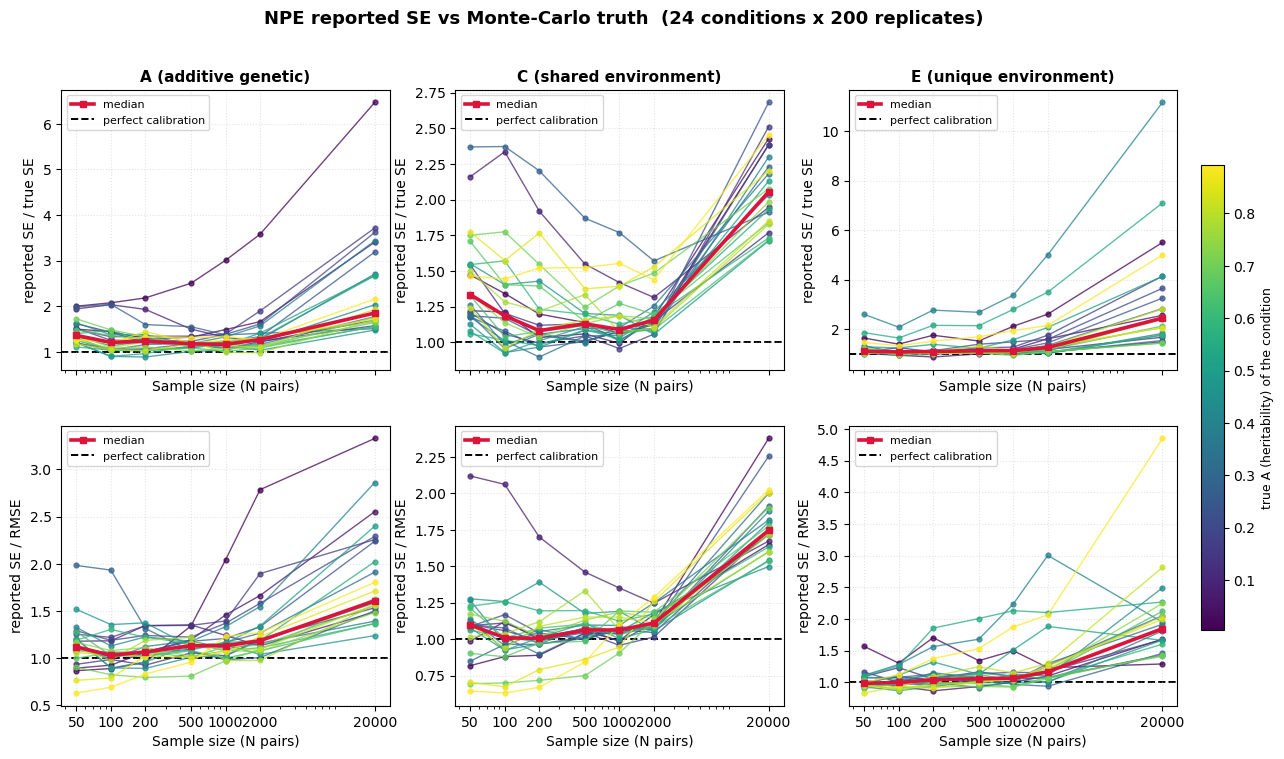

In [5]:
# -- Figure 1: calibration ratios vs N, one line per condition --------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
fig.suptitle("NPE reported SE vs Monte-Carlo truth  "
             f"({len(CONDITIONS)} conditions x {N_REPS} replicates)",
             fontsize=13, fontweight="bold")

for row, (metric, label) in enumerate([
    ("ratio_se",   "reported SE / true SE"),
    ("ratio_rmse", "reported SE / RMSE"),
]):
    for col, p in enumerate(PARAMS):
        ax = axes[row, col]
        sub = cal[cal.parameter == p]
        for cid in COND_ORDER:
            s = sub[sub.condition_id == cid].sort_values("sample_size")
            ax.plot(s.sample_size, s[metric], marker="o", ms=3.5, lw=1.0,
                    color=COND_COLOR[cid], alpha=0.75)
        med = sub.groupby("sample_size")[metric].median()
        ax.plot(med.index, med.values, color="crimson", lw=2.6,
                marker="s", ms=5, label="median", zorder=5)
        ax.axhline(1.0, color="black", lw=1.4, ls="--", zorder=1,
                   label="perfect calibration")
        if row == 0:
            ax.set_title(PARAM_LABELS[p], fontsize=11, fontweight="bold")
        size_axis(ax, label)
        ax.legend(fontsize=8)

sm = plt.cm.ScalarMappable(cmap=COND_CMAP,
                           norm=plt.Normalize(vmin=h2.min(), vmax=h2.max()))
cb = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cb.set_label("true A (heritability) of the condition", fontsize=9)

save_fig(fig, "calibration_ratio_vs_n")
plt.show()


  figure -> results/se_calibration/reported_vs_true_se.png


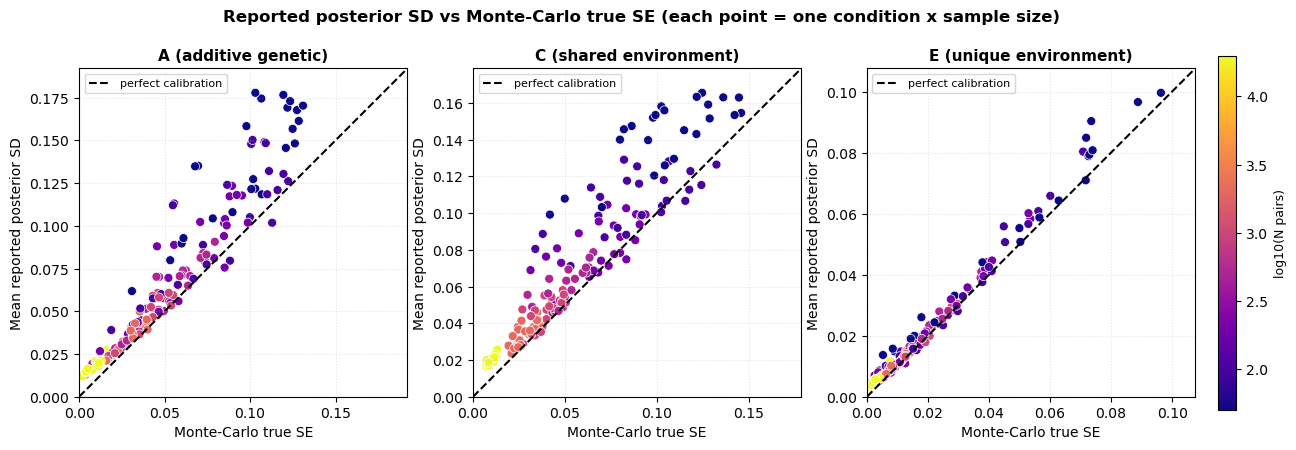

In [6]:
# -- Figure 2: reported SE vs true SE, identity line ------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
fig.suptitle("Reported posterior SD vs Monte-Carlo true SE "
             "(each point = one condition x sample size)",
             fontsize=12, fontweight="bold")

norm = plt.Normalize(np.log10(xs.min()), np.log10(xs.max()))
for ax, p in zip(axes, PARAMS):
    sub = cal[cal.parameter == p]
    sc = ax.scatter(sub.mc_se, sub.mean_post_sd, c=np.log10(sub.sample_size),
                    cmap="plasma", norm=norm, s=42, edgecolor="white", lw=0.5)
    lim = [0, max(sub.mc_se.max(), sub.mean_post_sd.max()) * 1.08]
    ax.plot(lim, lim, "k--", lw=1.5, label="perfect calibration")
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
    ax.set_xlabel("Monte-Carlo true SE", fontsize=10)
    ax.set_ylabel("Mean reported posterior SD", fontsize=10)
    ax.set_title(PARAM_LABELS[p], fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle=":")
    ax.legend(fontsize=8)

cb = fig.colorbar(sc, ax=axes, fraction=0.02, pad=0.02)
cb.set_label("log10(N pairs)", fontsize=9)

save_fig(fig, "reported_vs_true_se")
plt.show()


  figure -> results/se_calibration/ci_coverage_vs_n.png


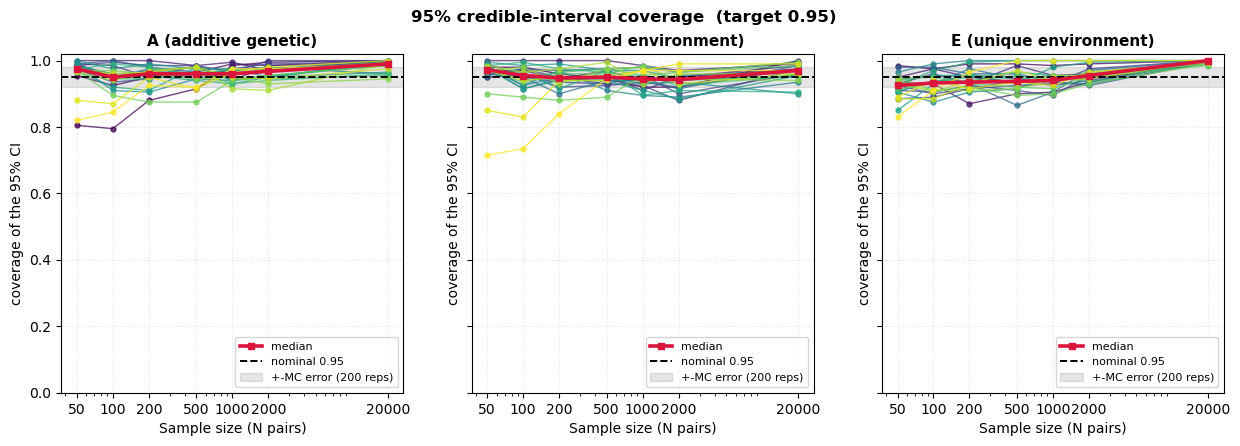


All STEP 07 outputs written to: /Users/xuly4739/Library/CloudStorage/OneDrive-UCB-O365/Documents/coding/PyProject/PGS_Cor_Relative/Scripts/nn_validate/ace_npe/results/se_calibration


In [7]:
# -- Figure 3: 95% credible-interval coverage -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
fig.suptitle("95% credible-interval coverage  (target 0.95)",
             fontsize=12, fontweight="bold")

# Binomial MC band on a coverage estimate from N_REPS replicates
band = 1.96 * np.sqrt(0.95 * 0.05 / N_REPS)

for ax, p in zip(axes, PARAMS):
    sub = cal[cal.parameter == p]
    for cid in COND_ORDER:
        s = sub[sub.condition_id == cid].sort_values("sample_size")
        ax.plot(s.sample_size, s.coverage95, marker="o", ms=3.5, lw=1.0,
                color=COND_COLOR[cid], alpha=0.75)
    med = sub.groupby("sample_size")["coverage95"].median()
    ax.plot(med.index, med.values, color="crimson", lw=2.6, marker="s", ms=5,
            label="median", zorder=5)
    ax.axhline(0.95, color="black", lw=1.4, ls="--", label="nominal 0.95")
    ax.axhspan(0.95 - band, 0.95 + band, color="black", alpha=0.10,
               label=f"+-MC error ({N_REPS} reps)")
    ax.set_title(PARAM_LABELS[p], fontsize=11, fontweight="bold")
    size_axis(ax, "coverage of the 95% CI")
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8, loc="lower right")

save_fig(fig, "ci_coverage_vs_n")
plt.show()

print(f"\nAll STEP 07 outputs written to: {SE_CAL_DIR}")
